# Stacking Ensemble — Zaragoza Solar Forecast

Combines TFT and XGBoost predictions using a **Ridge Regression meta-learner** (stacking).

**Concept:** Train two base models (TFT NWP, XGBoost NWP), then feed their predictions as
features into a simple combiner model. The combiner learns which base model to trust in
which conditions — e.g., "TFT is better on clear days, XGBoost handles sudden cloud shifts."

**Data flow:**
1. Generate TFT NWP predictions on val + test (aggregate overlapping 24h windows → 1 per timestep)
2. Generate XGBoost NWP predictions on val + test (already 1:1 per timestep)
3. Train Ridge Regression on val predictions (out-of-sample for both base models)
4. Evaluate on test set — touched exactly once

**Two meta-learner variants compared:**
- **Predictions only:** just TFT + XGBoost outputs
- **Predictions + context:** adds hour_sin, hour_cos, solar_zenith, clearsky_ghi for time-of-day weighting

**Prerequisites:** Notebooks 4c (TFT NWP training) and 7 (XGBoost baseline) must have been run.

## Step 0 — Imports & Configuration

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

from sklearn.linear_model import Ridge
import xgboost as xgb

# Patch torch.load to allow weights_only=False (safe for re-runs)
if not getattr(torch, '_orig_load', None):
    torch._orig_load = torch.load
def _patched_torch_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return torch._orig_load(*args, **kwargs)
torch.load = _patched_torch_load

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# ── Paths ──
DATA_DIR  = os.path.join(os.getcwd(), 'data')
MODEL_DIR = os.path.join(os.getcwd(), 'models')

# ── Sequence lengths (must match TFT training) ──
MAX_ENCODER_LENGTH    = 168
MAX_PREDICTION_LENGTH = 24

# ── NWP feature classification (from 4c / 5c) ──
KNOWN_FUTURE = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'doy_sin', 'doy_cos', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi',
    'ssrd_wm2_forecast', 'temperature_2m_C_forecast', 'dewpoint_2m_C_forecast',
    'surface_pressure_hPa_forecast', 'total_precip_mm_forecast',
    'kt_forecast', 'dewpoint_depression_C_forecast',
]
OBSERVED = [
    'dewpoint_2m_C', 'temperature_2m_C', 'surface_pressure_hPa',
    'total_precip_mm', 'ssrd_wm2', 'strd_wm2', 'kt', 'dewpoint_depression_C',
]
TARGET = 'pv_generation_mwh'

# ── Context features for enriched meta-learner ──
CONTEXT_FEATURES = ['hour_sin', 'hour_cos', 'solar_zenith', 'clearsky_ghi']

# ── Load preprocessing params ──
with open(os.path.join(DATA_DIR, 'nwp_preprocessing_params.json')) as f:
    pp = json.load(f)
TARGET_MEAN = pp['target_mean']
TARGET_STD  = pp['target_std']

print(f"Target denorm: z * {TARGET_STD:.4f} + {TARGET_MEAN:.4f}")
print(f"NWP known-future features: {len(KNOWN_FUTURE)}")
print(f"Observed features: {len(OBSERVED)}")

c:\Users\nicol\Documents\ML-solar-forecast\.venv\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


Target denorm: z * 443.4560 + 335.7786
NWP known-future features: 16
Observed features: 8


In [2]:
def denormalize(z_values):
    """Convert z-score normalized values back to original MWh scale."""
    return z_values * TARGET_STD + TARGET_MEAN


def compute_metrics(actual_mwh, predicted_mwh):
    """Compute RMSE, MAE, R² on original MWh scale."""
    residuals = actual_mwh - predicted_mwh
    mae  = np.abs(residuals).mean()
    rmse = np.sqrt((residuals ** 2).mean())
    ss_res = (residuals ** 2).sum()
    ss_tot = ((actual_mwh - actual_mwh.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    nrmse = (rmse / TARGET_MEAN) * 100  # normalized by train-set mean
    return {'MAE_MWh': float(mae), 'RMSE_MWh': float(rmse), 'R2': float(r2), 'nRMSE_pct': float(nrmse)}


def aggregate_windows(pred_z, n_timesteps):
    """Average all overlapping window predictions for each timestep.

    TFT produces (n_windows, 24) predictions. Window i predicts timesteps
    i through i+23. This function averages all predictions for each timestep,
    giving one prediction per timestep aligned with XGBoost's point predictions.
    """
    sums   = np.zeros(n_timesteps)
    counts = np.zeros(n_timesteps)
    n_windows, horizon = pred_z.shape
    for i in range(n_windows):
        for h in range(horizon):
            t = i + h
            if t < n_timesteps:
                sums[t] += pred_z[i, h]
                counts[t] += 1
    counts[counts == 0] = 1
    return sums / counts

## Step 1 — Load Data Splits

In [3]:
# ── Load NWP processed splits (used by both TFT and XGBoost) ──
train_df = pd.read_csv(os.path.join(DATA_DIR, 'nwp_train_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc').reset_index()
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'nwp_val_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc').reset_index()
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'nwp_test_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc').reset_index()

# ── Continuous time_idx across all splits (required for TimeSeriesDataSet) ──
train_df['time_idx'] = np.arange(len(train_df))
val_df['time_idx']   = np.arange(len(train_df), len(train_df) + len(val_df))
test_df['time_idx']  = np.arange(len(train_df) + len(val_df),
                                  len(train_df) + len(val_df) + len(test_df))

for df in [train_df, val_df, test_df]:
    df['group_id'] = '0'

print(f"Train: {len(train_df):,} rows  time_idx [0, {train_df['time_idx'].max()}]")
print(f"Val:   {len(val_df):,} rows   time_idx [{val_df['time_idx'].min()}, {val_df['time_idx'].max()}]")
print(f"Test:  {len(test_df):,} rows  time_idx [{test_df['time_idx'].min()}, {test_df['time_idx'].max()}]")

Train: 17,544 rows  time_idx [0, 17543]
Val:   4,344 rows   time_idx [17544, 21887]
Test:  4,416 rows  time_idx [21888, 26303]


## Step 2 — Generate TFT NWP Predictions (Val + Test)

Load the trained TFT NWP checkpoint and generate predictions on both validation and test sets.
The TFT produces `(n_windows, 24)` shaped output — we aggregate overlapping windows to get
one prediction per timestep, aligned with XGBoost's point predictions.

In [4]:
# ── Reconstruct training dataset (needed for from_dataset) ──
training_dataset = TimeSeriesDataSet(
    train_df,
    time_idx='time_idx',
    target=TARGET,
    group_ids=['group_id'],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    min_encoder_length=MAX_ENCODER_LENGTH,
    time_varying_known_reals=KNOWN_FUTURE,
    time_varying_unknown_reals=OBSERVED,
    target_normalizer=None,
    scalers={col: None for col in KNOWN_FUTURE + OBSERVED},
    add_relative_time_idx=True,
    add_encoder_length=True,
    allow_missing_timesteps=False,
)

# ── Val dataset with encoder context from train tail ──
val_with_context = pd.concat([
    train_df.iloc[-MAX_ENCODER_LENGTH:],
    val_df
], ignore_index=True)

val_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset, val_with_context, stop_randomization=True,
)
val_dataloader = val_dataset.to_dataloader(train=False, batch_size=64, num_workers=2)

# ── Test dataset with encoder context from val tail ──
test_with_context = pd.concat([
    val_df.iloc[-MAX_ENCODER_LENGTH:],
    test_df
], ignore_index=True)

test_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset, test_with_context, stop_randomization=True,
)
test_dataloader = test_dataset.to_dataloader(train=False, batch_size=64, num_workers=2)

print(f"Val dataset:  {len(val_dataset)} windows")
print(f"Test dataset: {len(test_dataset)} windows")

Val dataset:  4321 windows
Test dataset: 4393 windows


In [5]:
# ── Load TFT NWP model ──
tft_ckpt = os.path.join(MODEL_DIR, 'nwp_forecast', 'tft_nwp_best.ckpt')
tft_model = TemporalFusionTransformer.load_from_checkpoint(tft_ckpt)
tft_model.eval()
print(f"Loaded TFT NWP from {tft_ckpt}")
print(f"Parameters: {sum(p.numel() for p in tft_model.parameters()):,}")

# ── Generate val predictions ──
val_preds_raw = tft_model.predict(val_dataloader, mode='prediction', return_x=True, return_y=True)
val_pred_z  = val_preds_raw.output.cpu().numpy()   # (n_windows, 24)
val_actual_z = val_preds_raw.y[0].cpu().numpy()

# Aggregate overlapping windows → one prediction per val timestep
tft_val_pred_z   = aggregate_windows(val_pred_z, len(val_df))
tft_val_actual_z = aggregate_windows(val_actual_z, len(val_df))

# ── Generate test predictions ──
test_preds_raw = tft_model.predict(test_dataloader, mode='prediction', return_x=True, return_y=True)
test_pred_z  = test_preds_raw.output.cpu().numpy()
test_actual_z = test_preds_raw.y[0].cpu().numpy()

tft_test_pred_z   = aggregate_windows(test_pred_z, len(test_df))
tft_test_actual_z = aggregate_windows(test_actual_z, len(test_df))

# Denormalize
tft_val_pred_mwh  = np.clip(denormalize(tft_val_pred_z), 0, None)
tft_test_pred_mwh = np.clip(denormalize(tft_test_pred_z), 0, None)
val_actual_mwh    = denormalize(val_df[TARGET].values)
test_actual_mwh   = denormalize(test_df[TARGET].values)

print(f"\nTFT NWP val predictions:  {len(tft_val_pred_mwh)} timesteps")
print(f"TFT NWP test predictions: {len(tft_test_pred_mwh)} timesteps")

# Sanity check
tft_val_metrics = compute_metrics(val_actual_mwh, tft_val_pred_mwh)
tft_test_metrics = compute_metrics(test_actual_mwh, tft_test_pred_mwh)
print(f"\nTFT NWP sanity check (aggregated windows):")
print(f"  Val  — RMSE: {tft_val_metrics['RMSE_MWh']:.2f}, R²: {tft_val_metrics['R2']:.4f}")
print(f"  Test — RMSE: {tft_test_metrics['RMSE_MWh']:.2f}, R²: {tft_test_metrics['R2']:.4f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Loaded TFT NWP from c:\Users\nicol\Documents\ML-solar-forecast\zaragoza\models\nwp_forecast\tft_nwp_best.ckpt
Parameters: 603,127


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



TFT NWP val predictions:  4344 timesteps
TFT NWP test predictions: 4416 timesteps

TFT NWP sanity check (aggregated windows):
  Val  — RMSE: 172.31, R²: 0.8601
  Test — RMSE: 160.62, R²: 0.8969


## Step 3 — Generate XGBoost NWP Predictions (Val + Test)

Train XGBoost using **only known-future features** (same 16 features the TFT NWP decoder sees).
This ensures a fair comparison — no observed ERA5 weather at the target timestep.

Runs a quick 15-trial Optuna search (XGBoost trains in seconds) rather than loading HPs from
notebook 7, since those HPs were optimized for a different feature set.

In [6]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Fair feature set: only known_future (same as TFT NWP decoder) ──
NWP_FEATURES = KNOWN_FUTURE  # 16 features, no observed ERA5

X_train = train_df[NWP_FEATURES].values
y_train = train_df[TARGET].values
X_val   = val_df[NWP_FEATURES].values
y_val   = val_df[TARGET].values
X_test  = test_df[NWP_FEATURES].values
y_test  = test_df[TARGET].values

print(f"XGBoost features ({len(NWP_FEATURES)}): {NWP_FEATURES}")
print(f"(Same as TFT NWP decoder — no observed ERA5 at target timestep)")

# ── Optuna HP search (15 trials, fast for XGBoost) ──
def xgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    pred_z = model.predict(X_val)
    pred_mwh = np.clip(denormalize(pred_z), 0, None)
    actual_mwh = denormalize(y_val)
    return np.sqrt(((actual_mwh - pred_mwh) ** 2).mean())

study = optuna.create_study(direction='minimize', study_name='xgb_nwp_fair')
study.optimize(xgb_objective, n_trials=15)

print(f"\nBest trial: #{study.best_trial.number}")
print(f"Best val RMSE: {study.best_value:.2f} MWh")
print(f"Best params: {study.best_params}")

# ── Train final model with best HPs ──
xgb_model = xgb.XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# ── Generate predictions ──
xgb_val_pred_mwh  = np.clip(denormalize(xgb_model.predict(X_val)), 0, None)
xgb_test_pred_mwh = np.clip(denormalize(xgb_model.predict(X_test)), 0, None)

print(f"\nXGBoost NWP val predictions:  {len(xgb_val_pred_mwh)} timesteps")
print(f"XGBoost NWP test predictions: {len(xgb_test_pred_mwh)} timesteps")

# Sanity check
xgb_val_metrics  = compute_metrics(val_actual_mwh, xgb_val_pred_mwh)
xgb_test_metrics = compute_metrics(test_actual_mwh, xgb_test_pred_mwh)
print(f"\nXGBoost NWP (known-future only):")
print(f"  Val  — RMSE: {xgb_val_metrics['RMSE_MWh']:.2f}, R²: {xgb_val_metrics['R2']:.4f}")
print(f"  Test — RMSE: {xgb_test_metrics['RMSE_MWh']:.2f}, R²: {xgb_test_metrics['R2']:.4f}")

XGBoost features (16): ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi', 'ssrd_wm2_forecast', 'temperature_2m_C_forecast', 'dewpoint_2m_C_forecast', 'surface_pressure_hPa_forecast', 'total_precip_mm_forecast', 'kt_forecast', 'dewpoint_depression_C_forecast']
(Same as TFT NWP decoder — no observed ERA5 at target timestep)

Best trial: #3
Best val RMSE: 170.14 MWh
Best params: {'n_estimators': 905, 'max_depth': 3, 'learning_rate': 0.018234953007643637, 'subsample': 0.9696932852946948, 'colsample_bytree': 0.67479526528952, 'min_child_weight': 5, 'reg_alpha': 0.0007666806077813111, 'reg_lambda': 0.6252806471842067}

XGBoost NWP val predictions:  4344 timesteps
XGBoost NWP test predictions: 4416 timesteps

XGBoost NWP (known-future only):
  Val  — RMSE: 170.14, R²: 0.8636
  Test — RMSE: 167.77, R²: 0.8876


## Step 4 — Assemble Aligned Prediction DataFrames

Both base models now have one prediction per timestep. Combine into DataFrames for stacking.

In [7]:
# ── Build aligned DataFrames ──
val_preds = pd.DataFrame({
    'datetime_utc': val_df['datetime_utc'].values,
    'actual_mwh':   val_actual_mwh,
    'tft_nwp':      tft_val_pred_mwh,
    'xgb_nwp':      xgb_val_pred_mwh,
})
for feat in CONTEXT_FEATURES:
    val_preds[feat] = val_df[feat].values

test_preds = pd.DataFrame({
    'datetime_utc': test_df['datetime_utc'].values,
    'actual_mwh':   test_actual_mwh,
    'tft_nwp':      tft_test_pred_mwh,
    'xgb_nwp':      xgb_test_pred_mwh,
})
for feat in CONTEXT_FEATURES:
    test_preds[feat] = test_df[feat].values

print(f"Val predictions shape:  {val_preds.shape}")
print(f"Test predictions shape: {test_preds.shape}")

# ── Correlation matrix (sanity check) ──
corr_cols = ['actual_mwh', 'tft_nwp', 'xgb_nwp']
print("\nCorrelation matrix (val set):")
print(val_preds[corr_cols].corr().round(4).to_string())

print("\nCorrelation matrix (test set):")
print(test_preds[corr_cols].corr().round(4).to_string())

Val predictions shape:  (4344, 8)
Test predictions shape: (4416, 8)

Correlation matrix (val set):
            actual_mwh  tft_nwp  xgb_nwp
actual_mwh      1.0000   0.9305   0.9324
tft_nwp         0.9305   1.0000   0.9886
xgb_nwp         0.9324   0.9886   1.0000

Correlation matrix (test set):
            actual_mwh  tft_nwp  xgb_nwp
actual_mwh      1.0000   0.9503   0.9458
tft_nwp         0.9503   1.0000   0.9929
xgb_nwp         0.9458   0.9929   1.0000


## Step 5 — Train Meta-Learner (Ridge Regression)

Two variants:
1. **Predictions only** — features = [tft_nwp, xgb_nwp]
2. **Predictions + context** — adds hour_sin, hour_cos, solar_zenith, clearsky_ghi

The meta-learner trains on validation predictions (out-of-sample for both base models)
and is evaluated on the test set exactly once.

In [8]:
PRED_COLS = ['tft_nwp', 'xgb_nwp']

CONFIGS = {
    'Predictions only':    PRED_COLS,
    'Predictions + context': PRED_COLS + CONTEXT_FEATURES,
}

results = []
trained_models = {}

for config_name, feat_cols in CONFIGS.items():
    X_meta_train = val_preds[feat_cols].values
    y_meta_train = val_preds['actual_mwh'].values
    X_meta_test  = test_preds[feat_cols].values
    y_meta_test  = test_preds['actual_mwh'].values

    meta = Ridge(alpha=1.0)
    meta.fit(X_meta_train, y_meta_train)

    val_meta_pred  = np.clip(meta.predict(X_meta_train), 0, None)
    test_meta_pred = np.clip(meta.predict(X_meta_test), 0, None)

    val_m  = compute_metrics(y_meta_train, val_meta_pred)
    test_m = compute_metrics(y_meta_test, test_meta_pred)

    results.append({
        'config':    config_name,
        'val_RMSE':  val_m['RMSE_MWh'],
        'val_MAE':   val_m['MAE_MWh'],
        'val_R2':    val_m['R2'],
        'test_RMSE': test_m['RMSE_MWh'],
        'test_MAE':  test_m['MAE_MWh'],
        'test_R2':   test_m['R2'],
    })
    trained_models[config_name] = (meta, feat_cols, test_meta_pred)

results_df = pd.DataFrame(results)
print("=" * 75)
print("STACKING META-LEARNER COMPARISON")
print("=" * 75)
print(results_df.to_string(index=False, float_format='%.4f'))
print("=" * 75)

STACKING META-LEARNER COMPARISON
               config  val_RMSE  val_MAE  val_R2  test_RMSE  test_MAE  test_R2
     Predictions only  164.3286  97.0088  0.8727   157.5952   92.5023   0.9008
Predictions + context  159.1779  92.6350  0.8806   152.8585   90.6272   0.9067


In [9]:
# ── Select best config and inspect its weights ──
best_result = max(results, key=lambda r: r['val_R2'])  # select on val, not test
best_name = best_result['config']
best_meta, best_feat_cols, best_test_pred = trained_models[best_name]

print(f"Best config: {best_name}")
print(f"\nRidge coefficients (learned model weighting):")
for name, coef in zip(best_feat_cols, best_meta.coef_):
    print(f"  {name:35s}  weight = {coef:+.6f}")
print(f"  {'intercept':35s}  = {best_meta.intercept_:+.6f}")

# Interpretation: if both prediction weights are positive, both models contribute.
# A higher weight means the meta-learner trusts that model more on average.

Best config: Predictions + context

Ridge coefficients (learned model weighting):
  tft_nwp                              weight = +0.422631
  xgb_nwp                              weight = +0.696709
  hour_sin                             weight = +8.892190
  hour_cos                             weight = -113.901020
  solar_zenith                         weight = +32.291226
  clearsky_ghi                         weight = -72.092070
  intercept                            = -1.461464


## Step 6 — Full Model Comparison

Compare the stacking ensemble against all individual models and baselines.

In [10]:
# ── Baselines ──
test_gen = denormalize(test_df[TARGET].values)

# Persistence (24h)
persistence_pred    = test_gen[:-24]
persistence_actual  = test_gen[24:]
persistence_metrics = compute_metrics(persistence_actual, persistence_pred)

# Climatological (hourly mean from training set)
train_gen_mwh = denormalize(train_df[TARGET].values)
train_hours   = pd.to_datetime(train_df['datetime_utc']).dt.hour
hourly_means  = pd.Series(train_gen_mwh, index=train_hours.values).groupby(level=0).mean()
test_hours    = pd.to_datetime(test_df['datetime_utc']).dt.hour.values
clim_pred     = hourly_means.loc[test_hours].values
clim_metrics  = compute_metrics(test_gen, clim_pred)

# ── Load individual model results ──
all_models = {}

# Baselines
all_models['Persistence (24h)']    = persistence_metrics
all_models['Climatological']       = clim_metrics

# TFT NWP (from this notebook)
all_models['TFT NWP']             = tft_test_metrics

# XGBoost NWP (from this notebook)
all_models['XGBoost NWP']         = xgb_test_metrics

# TFT Standard (load if available)
std_hp_path = os.path.join(os.getcwd(), 'models', 'standard', 'hp_study_results.json')
if os.path.exists(std_hp_path):
    with open(std_hp_path) as f:
        std_data = json.load(f)
    if 'test_metrics_mwh' in std_data:
        all_models['TFT Standard'] = std_data['test_metrics_mwh']

# XGBoost Standard (load if available)
xgb_std_path = os.path.join(os.getcwd(), 'models', 'xgboost', 'xgboost_hp_study_results.json')
if os.path.exists(xgb_std_path):
    with open(xgb_std_path) as f:
        xgb_std_data = json.load(f)
    if 'test_metrics_mwh' in xgb_std_data:
        all_models['XGBoost Standard'] = xgb_std_data['test_metrics_mwh']

# Stacking ensemble (best config)
ensemble_metrics = compute_metrics(test_actual_mwh, best_test_pred)
all_models[f'Stacking ({best_name})'] = ensemble_metrics

# ── Print comparison table ──
print("=" * 70)
print("FULL MODEL COMPARISON — Zaragoza Solar Forecast (Test Set)")
print("=" * 70)
print(f"\n{'Model':<35s} {'RMSE (MWh)':>12s} {'MAE (MWh)':>12s} {'R²':>8s}")
print("-" * 70)
for model_name, m in all_models.items():
    print(f"{model_name:<35s} {m['RMSE_MWh']:12.2f} {m['MAE_MWh']:12.2f} {m['R2']:8.4f}")
print("=" * 70)

# ── Improvement over best individual model ──
best_individual_r2 = max(tft_test_metrics['R2'], xgb_test_metrics['R2'])
best_individual_name = 'TFT NWP' if tft_test_metrics['R2'] > xgb_test_metrics['R2'] else 'XGBoost NWP'
print(f"\nBest individual model: {best_individual_name} (R² = {best_individual_r2:.4f})")
print(f"Stacking ensemble:    R² = {ensemble_metrics['R2']:.4f}")
print(f"Improvement:          ΔR² = {ensemble_metrics['R2'] - best_individual_r2:+.4f}")

FULL MODEL COMPARISON — Zaragoza Solar Forecast (Test Set)

Model                                 RMSE (MWh)    MAE (MWh)       R²
----------------------------------------------------------------------
Persistence (24h)                         236.37       116.24   0.7755
Climatological                            279.57       173.41   0.6878
TFT NWP                                   160.62        86.88   0.8969
XGBoost NWP                               167.77        92.93   0.8876
TFT Standard                              193.75       103.77   0.8501
XGBoost Standard                          216.18       123.82   0.8133
Stacking (Predictions + context)          152.86        90.63   0.9067

Best individual model: TFT NWP (R² = 0.8969)
Stacking ensemble:    R² = 0.9067
Improvement:          ΔR² = +0.0097


## Step 7 — Visualizations

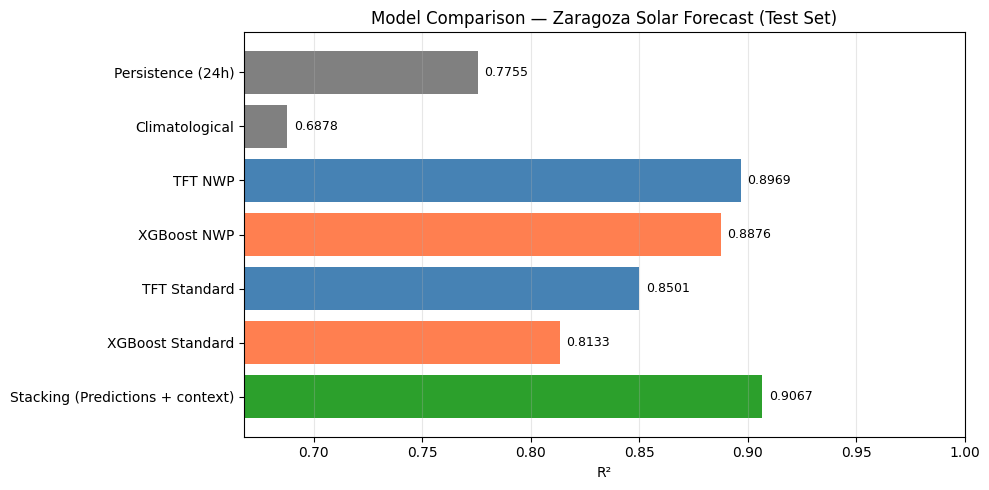

In [11]:
# ── 7a: R² bar chart across all models ──
model_names = list(all_models.keys())
r2_values   = [all_models[m]['R2'] for m in model_names]

colors = []
for name in model_names:
    if 'Stacking' in name:
        colors.append('#2ca02c')   # green for ensemble
    elif 'TFT' in name:
        colors.append('steelblue')
    elif 'XGBoost' in name:
        colors.append('coral')
    else:
        colors.append('gray')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(model_names)), r2_values, color=colors)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names)
ax.set_xlabel('R²')
ax.set_title('Model Comparison — Zaragoza Solar Forecast (Test Set)')
ax.set_xlim(min(r2_values) - 0.02, 1.0)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

for bar, val in zip(bars, r2_values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

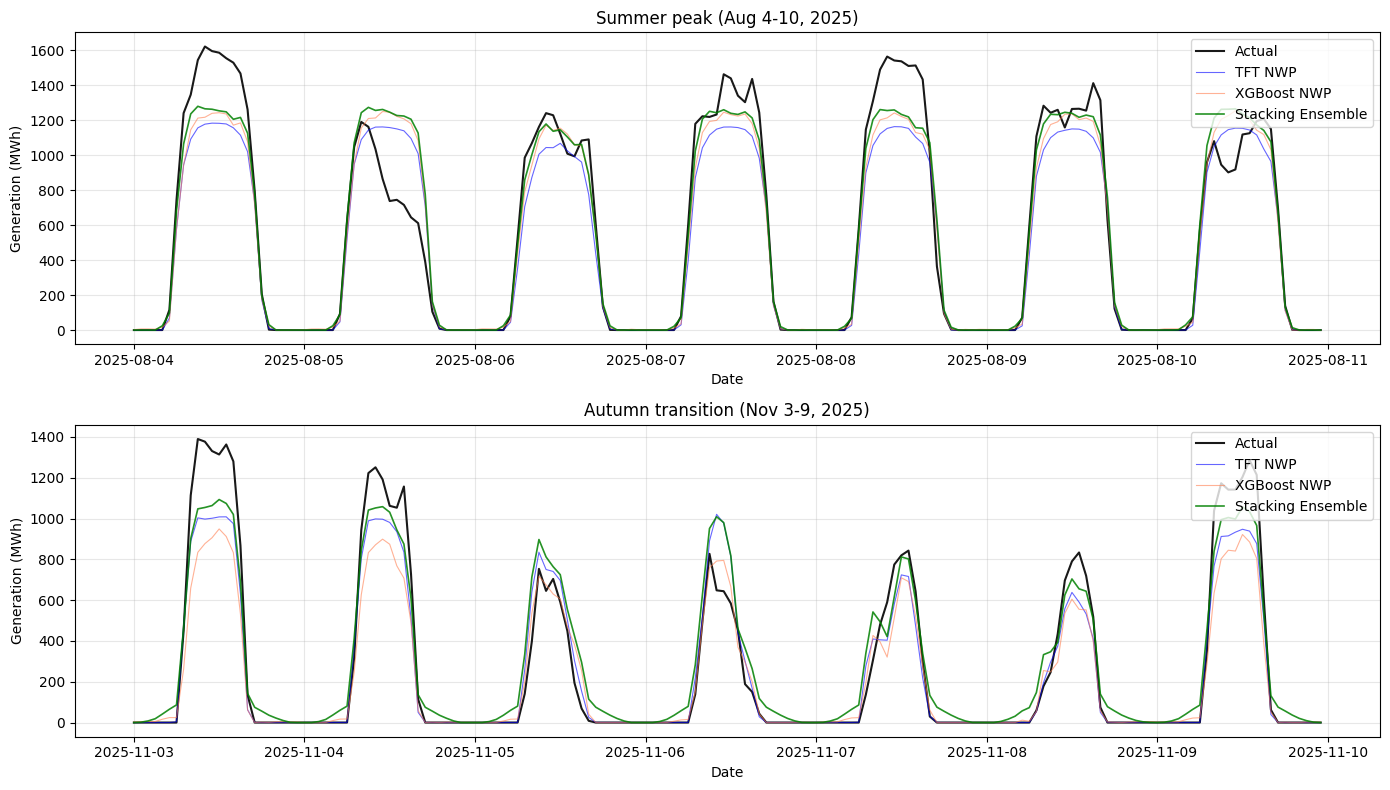

In [12]:
# ── 7b: Time series — selected test weeks (Ensemble vs individual models) ──
test_datetime = pd.to_datetime(test_preds['datetime_utc'])

week_starts = [
    ('Summer peak (Aug 4-10, 2025)', '2025-08-04', '2025-08-10'),
    ('Autumn transition (Nov 3-9, 2025)', '2025-11-03', '2025-11-09'),
]

fig, axes = plt.subplots(len(week_starts), 1, figsize=(14, 4 * len(week_starts)))
if len(week_starts) == 1:
    axes = [axes]

for ax, (title, start, end) in zip(axes, week_starts):
    mask = (test_datetime >= start) & (test_datetime <= end + ' 23:00:00')

    ax.plot(test_datetime[mask], test_preds.loc[mask, 'actual_mwh'].values,
            'k-', linewidth=1.5, label='Actual', alpha=0.9)
    ax.plot(test_datetime[mask], test_preds.loc[mask, 'tft_nwp'].values,
            'b-', linewidth=0.8, label='TFT NWP', alpha=0.6)
    ax.plot(test_datetime[mask], test_preds.loc[mask, 'xgb_nwp'].values,
            color='coral', linewidth=0.8, label='XGBoost NWP', alpha=0.6)
    ax.plot(test_datetime[mask], best_test_pred[mask],
            'g-', linewidth=1.2, label=f'Stacking Ensemble', alpha=0.85)
    ax.set_xlabel('Date')
    ax.set_ylabel('Generation (MWh)')
    ax.set_title(title)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

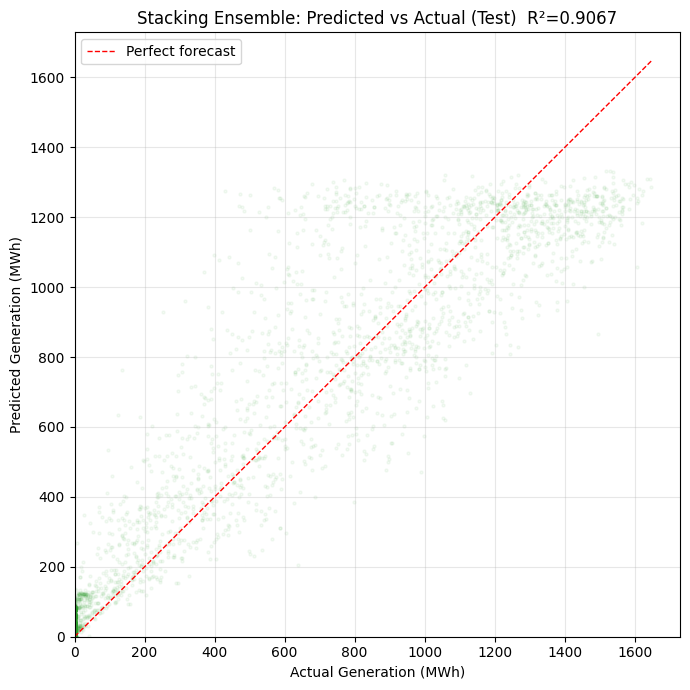

In [13]:
# ── 7c: Scatter plot — Ensemble predicted vs actual ──
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(test_actual_mwh, best_test_pred, alpha=0.05, s=5, c='#2ca02c')
max_val = max(test_actual_mwh.max(), best_test_pred.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect forecast')
ax.set_xlabel('Actual Generation (MWh)')
ax.set_ylabel('Predicted Generation (MWh)')
ax.set_title(f'Stacking Ensemble: Predicted vs Actual (Test)  R²={ensemble_metrics["R2"]:.4f}')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max_val * 1.05)
ax.set_ylim(0, max_val * 1.05)
plt.tight_layout()
plt.show()

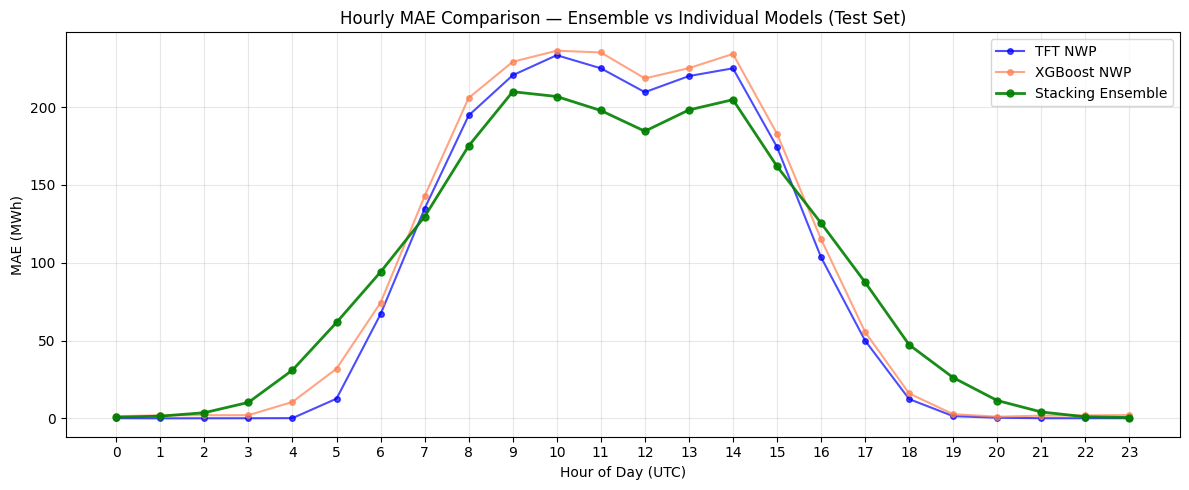

In [14]:
# ── 7d: Residual comparison by hour-of-day ──
test_hours_arr = pd.to_datetime(test_preds['datetime_utc']).dt.hour.values

ensemble_residuals = test_actual_mwh - best_test_pred
tft_residuals      = test_actual_mwh - tft_test_pred_mwh
xgb_residuals      = test_actual_mwh - xgb_test_pred_mwh

# Compute MAE by hour for each model
hourly_data = pd.DataFrame({
    'hour': test_hours_arr,
    'ensemble_abs_err': np.abs(ensemble_residuals),
    'tft_abs_err':      np.abs(tft_residuals),
    'xgb_abs_err':      np.abs(xgb_residuals),
})
hourly_mae = hourly_data.groupby('hour').mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_mae.index, hourly_mae['tft_abs_err'], 'b-o', markersize=4,
        label='TFT NWP', alpha=0.7)
ax.plot(hourly_mae.index, hourly_mae['xgb_abs_err'], color='coral', marker='o',
        markersize=4, label='XGBoost NWP', alpha=0.7)
ax.plot(hourly_mae.index, hourly_mae['ensemble_abs_err'], 'g-o', markersize=5,
        linewidth=2, label='Stacking Ensemble', alpha=0.9)
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('MAE (MWh)')
ax.set_title('Hourly MAE Comparison — Ensemble vs Individual Models (Test Set)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

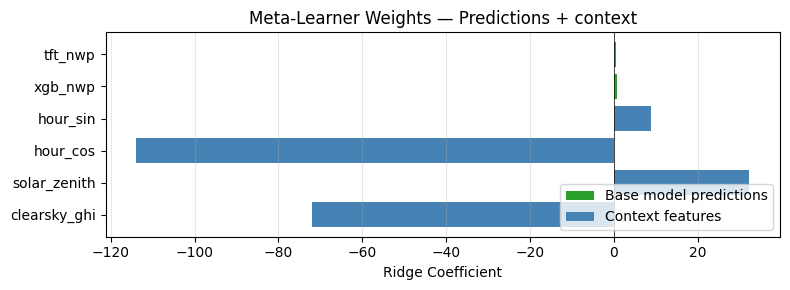

In [15]:
# ── 7e: Meta-learner weight visualization ──
fig, ax = plt.subplots(figsize=(8, max(3, len(best_feat_cols) * 0.5)))
coefs = best_meta.coef_
bar_colors = ['#2ca02c' if c in PRED_COLS else 'steelblue' for c in best_feat_cols]
ax.barh(range(len(best_feat_cols)), coefs, color=bar_colors)
ax.set_yticks(range(len(best_feat_cols)))
ax.set_yticklabels(best_feat_cols)
ax.set_xlabel('Ridge Coefficient')
ax.set_title(f'Meta-Learner Weights — {best_name}')
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#2ca02c', label='Base model predictions'),
    Patch(facecolor='steelblue', label='Context features'),
], loc='lower right')

plt.tight_layout()
plt.show()

## Step 8 — Save Results

In [16]:
# ── Save stacking results JSON ──
stacking_output = {
    'model': 'stacking_ensemble',
    'best_config': best_name,
    'meta_learner': 'Ridge(alpha=1.0)',
    'base_models': PRED_COLS,
    'feature_cols': best_feat_cols,
    'meta_weights': dict(zip(best_feat_cols, best_meta.coef_.tolist())),
    'meta_intercept': float(best_meta.intercept_),
    'val_metrics_mwh': {
        'RMSE_MWh': best_result['val_RMSE'],
        'MAE_MWh':  best_result['val_MAE'],
        'R2':       best_result['val_R2'],
    },
    'test_metrics_mwh': ensemble_metrics,
    'all_configs': results,
    'base_model_test_metrics': {
        'tft_nwp':  tft_test_metrics,
        'xgb_nwp':  xgb_test_metrics,
    },
}

os.makedirs(MODEL_DIR, exist_ok=True)
out_path = os.path.join(MODEL_DIR, 'stacking_results.json')
with open(out_path, 'w') as f:
    json.dump(stacking_output, f, indent=2)
print(f"Saved: {out_path}")

# ── Save test predictions CSV ──
test_preds_out = test_preds[['datetime_utc', 'actual_mwh']].copy()
test_preds_out['tft_nwp_pred_mwh']    = tft_test_pred_mwh
test_preds_out['xgb_nwp_pred_mwh']    = xgb_test_pred_mwh
test_preds_out['ensemble_pred_mwh']   = best_test_pred
csv_path = os.path.join(MODEL_DIR, 'stacking_predictions_test.csv')
test_preds_out.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

Saved: c:\Users\nicol\Documents\ML-solar-forecast\zaragoza\models\stacking_results.json
Saved: c:\Users\nicol\Documents\ML-solar-forecast\zaragoza\models\stacking_predictions_test.csv


## Step 9 — Summary

In [17]:
print("=" * 70)
print("FINAL RESULTS — Zaragoza Stacking Ensemble")
print("=" * 70)

print(f"\nMeta-learner: Ridge Regression (alpha=1.0)")
print(f"Best config:  {best_name}")
print(f"Base models:  TFT NWP + XGBoost NWP")

print(f"\n{'':35s} {'Val':>12s} {'Test':>12s}")
print("-" * 62)
for metric in ['RMSE_MWh', 'MAE_MWh', 'R2']:
    val_v  = stacking_output['val_metrics_mwh'][metric]
    test_v = ensemble_metrics[metric]
    fmt = '.2f' if 'MWh' in metric else '.4f'
    print(f"{'Ensemble ' + metric:<35s} {val_v:12{fmt}} {test_v:12{fmt}}")

print(f"\n{'Base model comparison (test):'}")
print(f"  TFT NWP:             R² = {tft_test_metrics['R2']:.4f}  RMSE = {tft_test_metrics['RMSE_MWh']:.2f}")
print(f"  XGBoost NWP:         R² = {xgb_test_metrics['R2']:.4f}  RMSE = {xgb_test_metrics['RMSE_MWh']:.2f}")
print(f"  Stacking Ensemble:   R² = {ensemble_metrics['R2']:.4f}  RMSE = {ensemble_metrics['RMSE_MWh']:.2f}")

print(f"\nMeta-learner weights:")
for name, coef in zip(best_feat_cols, best_meta.coef_):
    print(f"  {name:35s} {coef:+.6f}")
print(f"  {'intercept':35s} {best_meta.intercept_:+.6f}")
print("=" * 70)

FINAL RESULTS — Zaragoza Stacking Ensemble

Meta-learner: Ridge Regression (alpha=1.0)
Best config:  Predictions + context
Base models:  TFT NWP + XGBoost NWP

                                             Val         Test
--------------------------------------------------------------
Ensemble RMSE_MWh                         159.18       152.86
Ensemble MAE_MWh                           92.63        90.63
Ensemble R2                               0.8806       0.9067

Base model comparison (test):
  TFT NWP:             R² = 0.8969  RMSE = 160.62
  XGBoost NWP:         R² = 0.8876  RMSE = 167.77
  Stacking Ensemble:   R² = 0.9067  RMSE = 152.86

Meta-learner weights:
  tft_nwp                             +0.422631
  xgb_nwp                             +0.696709
  hour_sin                            +8.892190
  hour_cos                            -113.901020
  solar_zenith                        +32.291226
  clearsky_ghi                        -72.092070
  intercept                      

In [18]:
# Free GPU memory before moving to next notebook
import torch, gc
gc.collect()
torch.cuda.empty_cache()
print("GPU memory released.")

GPU memory released.
